# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# Проект спринта 11: прогноз оттока клиентов

## Постановка задачи

В рамках проекта необходимо построить модель **бинарной классификации** для прогноза оттока клиентов сервиса доставки кофе **Happy Beans Coffee**.

Целевая переменная:
- `churn`
  - `0` — клиент остаётся
  - `1` — клиент уходит

Задача модели:
предсказать вероятность того, что текущий клиент перестанет пользоваться сервисом **в следующем месяце**.

---

## Бизнес-контекст

Для сервиса доставки кофе удержание клиента значительно дешевле, чем привлечение нового: стоимость привлечения нового покупателя выше примерно в **5–7 раз**.

На текущий момент компания сталкивается с заметным ежемесячным оттоком клиентов, что приводит к:
- снижению ежемесячной выручки,
- неэффективному расходованию маркетингового бюджета,
- ухудшению прогнозируемости доходов,
- снижению ценности клиентской базы.

Результат проекта должен помочь бизнесу:
- заранее выявлять клиентов с высоким риском ухода,
- точечно запускать retention-меры,
- снижать расходы на неэффективный маркетинг,
- лучше планировать будущие доходы.

---

## Ограничения и требования к решению

### Требования к модели
- задача решается как **бинарная классификация**;
- модель должна быть **интерпретируемой**;
- в качестве основной модели рассматривается **линейный алгоритм**, прежде всего `LogisticRegression`;
- в качестве baseline используется `DummyClassifier`.

### Требования к обучению
- во всех алгоритмах, где это возможно, фиксируется `random_state`;
- пропущенные значения должны обрабатываться внутри общего пайплайна;
- оценка качества выполняется с помощью **кросс-валидации**;
- решение должно быть пригодно к дальнейшему использованию в проде:
  сохраняется **не только модель, но и весь pipeline предобработки**.

### Требования к артефактам
- итоговая модель и pipeline сохраняются через `pickle` или `joblib`;
- в ноутбуке должны быть зафиксированы финальные метрики и конфигурация лучшего решения.

---

## Особенности данных

Источник данных:
внутренние системы компании, включая:
- транзакционные данные,
- логи мобильного приложения,
- результаты пользовательских опросов.

Особенности датасета:
- признаки агрегированы за **последние 4 недели**;
- каждая строка соответствует **одному уникальному клиенту**;
- датасет представляет собой **готовую аналитическую витрину**;
- признаки уже рассчитаны и представлены в виде числовых и категориальных переменных.

---

## Выбор метрики

Для бизнеса ошибка разных типов имеет разную стоимость.

### Что критично:
- **False Positive**: модель считает, что клиент уйдёт, хотя он лоялен
  - лишние затраты на скидки, промокоды и удерживающие кампании;
- **False Negative**: модель не выявила клиента, который реально уйдёт
  - потеря клиента и будущей выручки.

### Рассматриваемые метрики
- **Recall** показывает, какую долю реально уходящих клиентов модель смогла найти;
- **Precision** показывает, какая доля клиентов, помеченных моделью как уходящие, действительно уйдёт;
- **F1-score** даёт компромисс между Precision и Recall;
- **PR AUC** оценивает качество модели по всей кривой Precision-Recall.

С учётом сильного дисбаланса классов основная метрика для **сравнения конфигураций модели на CV** — **PR AUC (`average_precision`)**. Она устойчивее к дисбалансу и лучше отражает качество ранжирования именно для редкого положительного класса.

При этом **Precision**, **Recall** и **F1-score** также сохраняются в анализе как прикладные метрики, поскольку после выбора лучшей конфигурации потребуется подобрать рабочий порог классификации и оценить компромисс между точностью удерживающих кампаний и охватом клиентов с риском оттока.

## Выбранный подход к моделированию

Базовый стек решения:
- `DummyClassifier` как baseline;
- `LogisticRegression` как интерпретируемая основная модель;
- `Pipeline` / `ColumnTransformer` для объединения предобработки и модели;
- кросс-валидация для устойчивой оценки качества;
- последующий подбор гиперпараметров;
- отдельная финальная проверка на test только после выбора конфигурации модели и порога.

## План работы

В рамках ноутбука будут выполнены следующие этапы:

1. Подготовка среды и импорт библиотек
2. Первичный анализ данных (EDA)
3. Предобработка данных
4. Обучение и оценка baseline-модели
5. Генерация и отбор новых признаков
6. Подбор гиперпараметров
7. Обучение финальной модели
8. Оценка качества на тестовой выборке
9. Сохранение модели и pipeline
10. Итоговый вывод по качеству и бизнес-интерпретации результата


## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    cross_val_predict,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import joblib


In [2]:
from importlib.metadata import version

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'joblib'
]

requirements_text = '\n'.join(
    f'{pkg}=={version(pkg)}' for pkg in packages
)

with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements_text)

print(requirements_text)


pandas==3.0.1
numpy==2.4.2
matplotlib==3.10.8
seaborn==0.13.2
scikit-learn==1.8.0
joblib==1.5.3


In [3]:
try:
    df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
except FileNotFoundError:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
df.shape

(10450, 27)

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [4]:
check = pd.concat([df.head(), df.sample(5),  df.tail()])
display(check)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
9583,user_05966,11.0,2.468470,0.622326,NaN,540.079357,1140.067383,NaN,0.262312,arabica,...,1.0,3.253391,3.081877,2.0,autumn,20.0,web,0.0,geo_88,0
9331,user_00943,8.0,9.022964,2.074779,422.441857,193.284557,1760.018574,326.647847,0.059418,arabica,...,1.0,4.907371,NaN,1.0,winter,NaN,android,0.0,geo_1,0
5777,user_08024,1.0,1.492512,0.487927,942.644153,675.943040,814.083122,269.922490,0.389890,NaN,...,1.0,4.913363,3.096325,2.0,summer,18.0,ios,1.0,geo_10,0
10122,user_08319,3.0,7.655292,1.898814,452.913858,NaN,1736.121723,260.037273,0.345822,arabica,...,1.0,4.766289,4.373449,1.0,autumn,4.0,android,0.0,geo_19,1
4105,user_05171,4.0,1.980016,0.360113,601.532576,198.498634,326.903291,52.678091,0.401608,blend,...,0.0,NaN,4.868692,1.0,NaN,3.0,android,0.0,geo_2,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

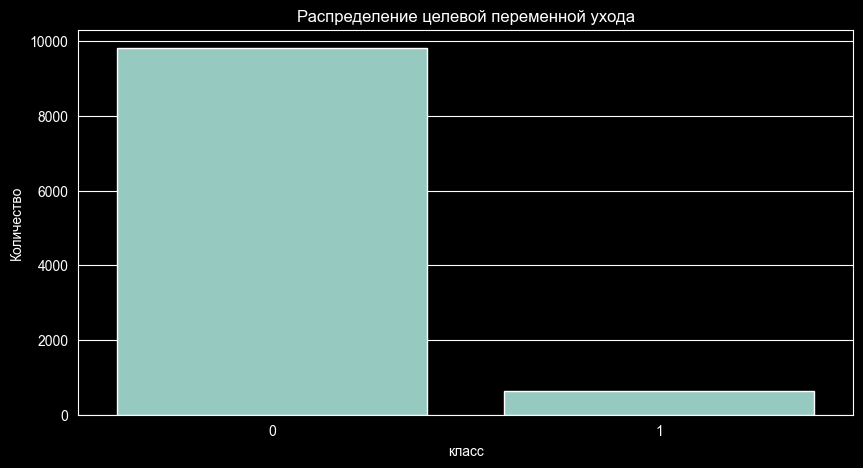

churn
0    93.980861
1     6.019139
Name: count, dtype: float64

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='churn')
plt.title('Распределение целевой переменной ухода')
plt.xlabel('класс')
plt.ylabel('Количество')
plt.show()
val = df['churn'].value_counts(dropna=False) / len(df['churn']) * 100
display(val)

In [7]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [8]:
def eda(df):
    eda_cols = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True)
    }).reset_index().rename(columns={'index': 'column'})
    display(eda_cols)
eda(df)

,column,dtype,nulls,null_pct,nunique
0,user_id,str,0,0.00,10450
1,days_since_last_order,float64,945,9.04,39
2,order_frequency_month,float64,600,5.74,9419
3,order_frequency_week,float64,388,3.71,9625
4,avg_order_value,float64,583,5.58,9441
5,median_order_value,float64,831,7.95,9201
6,total_spent_last_month,float64,294,2.81,9713
7,total_spent_last_week,float64,944,9.03,9090
8,discount_usage_rate,float64,397,3.80,9618
9,last_coffee_type,str,258,2.47,3


## Дополнение к EDA по связи признаков с churn

Ниже отдельно сравниваются ключевые числовые и категориальные признаки по целевой переменной, а также проверяется, связаны ли пропуски с классом `churn`. Это позволяет опираться не только на общее распределение признаков, но и на их поведение в разрезе целевой переменной.


churn,median_churn_0,median_churn_1,relative_diff_pct
app_opens_per_week,9.091142,11.780619,29.58
total_spent_last_month,1283.371589,1518.289206,18.30
order_frequency_week,0.776636,0.916824,18.05
days_since_last_promo,10.000000,11.000000,10.00
review_rating_last_1,3.989438,4.002388,0.32
days_since_last_order,3.000000,3.000000,0.00
review_rating_last_10,4.212054,4.141119,-1.68


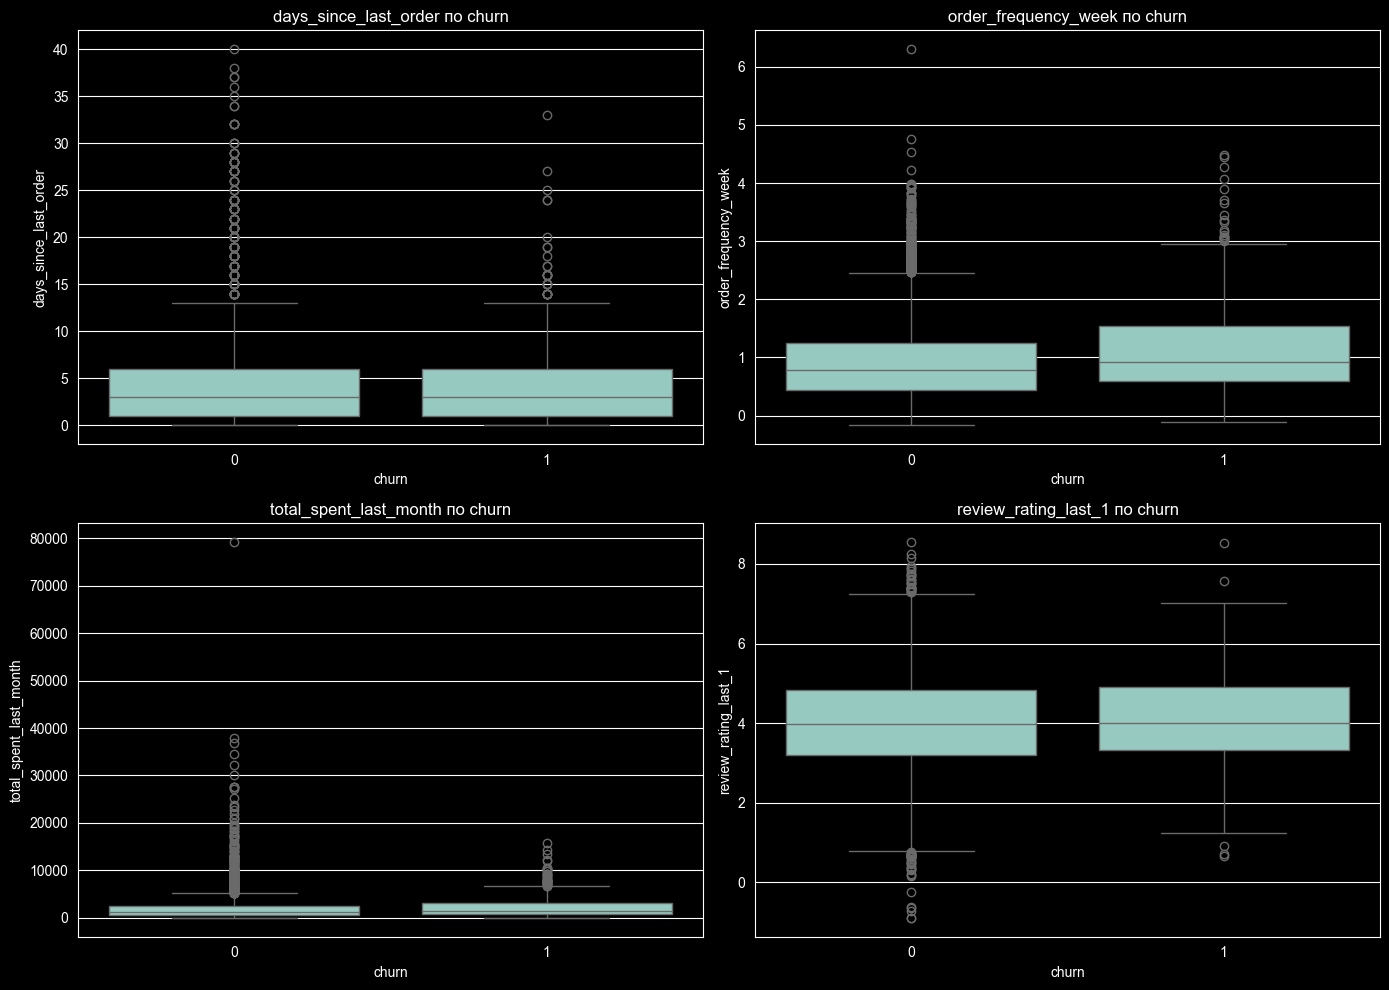

In [9]:
numeric_churn_cols = [
    'days_since_last_order',
    'order_frequency_week',
    'total_spent_last_month',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'days_since_last_promo'
]

churn_numeric_summary = (
    df.groupby('churn')[numeric_churn_cols]
    .median()
    .T
    .rename(columns={0: 'median_churn_0', 1: 'median_churn_1'})
)

churn_numeric_summary['relative_diff_pct'] = (
    (churn_numeric_summary['median_churn_1'] - churn_numeric_summary['median_churn_0'])
    / churn_numeric_summary['median_churn_0'].replace(0, np.nan)
    * 100
).round(2)

display(churn_numeric_summary.sort_values('relative_diff_pct', ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_cols = [
    'days_since_last_order',
    'order_frequency_week',
    'total_spent_last_month',
    'review_rating_last_1'
]

for ax, col in zip(axes.flat, plot_cols):
    sns.boxplot(data=df, x='churn', y=col, ax=ax)
    ax.set_title(f'{col} по churn')

plt.tight_layout()
plt.show()


In [10]:
missing_by_churn = (
    df.isna()
    .groupby(df['churn'])
    .mean()
    .T
    .rename(columns={0: 'missing_rate_churn_0', 1: 'missing_rate_churn_1'})
)

missing_by_churn['diff_pp'] = (
    (missing_by_churn['missing_rate_churn_1'] - missing_by_churn['missing_rate_churn_0']) * 100
).round(2)

display(
    missing_by_churn.sort_values('diff_pp', key=lambda s: s.abs(), ascending=False).head(15)
)

cat_churn_cols = [
    'subscription_status',
    'last_coffee_type',
    'preferred_roast',
    'phone_type',
    'seasons',
    'geo_location'
]

cat_churn_summary = []
for col in cat_churn_cols:
    tmp = (
        df.groupby(col, dropna=False)['churn']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'churn_rate', 'count': 'count'})
        .reset_index()
        .sort_values('count', ascending=False)
        .head(6)
    )
    tmp.insert(0, 'feature', col)
    tmp['churn_rate'] = tmp['churn_rate'].round(4)
    cat_churn_summary.append(tmp)

display(pd.concat(cat_churn_summary, ignore_index=True))


churn,missing_rate_churn_0,missing_rate_churn_1,diff_pp
seasonal_menu_tried,0.096121,0.071542,-2.46
seasons,0.063639,0.085851,2.22
order_frequency_month,0.056206,0.076312,2.01
last_drink_size,0.047042,0.066773,1.97
total_spent_last_week,0.089400,0.104928,1.55
avg_order_value,0.054882,0.069952,1.51
phone_type,0.032991,0.019078,-1.39
median_order_value,0.078709,0.092210,1.35
app_opens_per_week,0.086549,0.073132,-1.34
subscription_status,0.090520,0.077901,-1.26


,feature,subscription_status,churn_rate,count,last_coffee_type,preferred_roast,phone_type,seasons,geo_location
0,subscription_status,none,0.0502,3803,NaN,NaN,NaN,NaN,NaN
1,subscription_status,basic,0.0538,2862,NaN,NaN,NaN,NaN,NaN
2,subscription_status,premium,0.0702,1923,NaN,NaN,NaN,NaN,NaN
3,subscription_status,NaN,0.0522,938,NaN,NaN,NaN,NaN,NaN
4,subscription_status,pro,0.1082,924,NaN,NaN,NaN,NaN,NaN
5,last_coffee_type,NaN,0.0572,6134,arabica,NaN,NaN,NaN,NaN
6,last_coffee_type,NaN,0.0662,2524,robusta,NaN,NaN,NaN,NaN
7,last_coffee_type,NaN,0.0606,1534,blend,NaN,NaN,NaN,NaN
8,last_coffee_type,NaN,0.0698,258,NaN,NaN,NaN,NaN,NaN
9,preferred_roast,NaN,0.0607,3458,NaN,medium,NaN,NaN,NaN


Целевая переменная (ушел ли клиент) имеет большой дисбаланс классов, положительный класс заполняет всего 6 процентов от общего датасета.

## Анализ данных, описание и гипотезы

Все признаки в датасете можно разделить на несколько смысловых групп: признаки активности клиента, денежного поведения, продуктовых предпочтений, взаимодействия с приложением и технические признаки.

### 1. Признаки активности и вовлеченности клиента

#### Числовые

`days_since_last_order` — признак имеет `39` уникальных значений, `945` (`9.04 %`) пропусков, значения лежат в диапазоне от `0` до `40` дней. Из-за пропусков он хранится в типе `float64`, хотя по смыслу ближе к целочисленному. Это важный признак, отражающий давность последней активности клиента: чем больше дней прошло с последнего заказа, тем выше может быть риск оттока. В дальнейшем имеет смысл проверить гипотезу о разбиении признака на `bins`: `купили недавно` — от `0` до `7` дней, `купили в этом месяце` — от `8` до `30`, `покупали давно` — от `31` до `40`.

`order_frequency_month` — среднее количество заказов за последний месяц, `600` (`5.74 %`) пропусков, тип данных `float64`. Минимум — `0.011`, максимум — `27.389`. Признак хорошо описывает общую интенсивность использования сервиса. Потенциально может быть связан с `order_frequency_week`, поэтому дальше стоит проверить гипотезу о мультиколлинеарности.

`order_frequency_week` — среднее количество заказов за последнюю неделю, `388` (`3.71 %`) пропусков. Минимальное значение отрицательное: `-0.169`, максимальное — `6.303`. Отрицательная частота выглядит подозрительно и может быть следствием особенностей расчета, ошибок агрегации или выбросов, поэтому этот признак нужно дополнительно проверить. По смыслу он тоже отражает активность клиента и может оказаться особенно полезным для выявления клиентов, которые начали реже пользоваться сервисом именно в последние дни.

`app_opens_per_week` — среднее количество открытий приложения за неделю, `896` (`8.57 %`) пропусков. Минимум — `0`, максимум — `224.588`, медиана — около `9.23`. Признак характеризует цифровую вовлеченность клиента. Очень большие значения могут указывать как на крайне активных пользователей, так и на выбросы. Для дальнейшего анализа можно проверить гипотезу о разбиении на интервалы по уровню вовлеченности: `низкая`, `средняя`, `высокая` активность.

`days_since_last_promo` — количество дней с момента последнего использования промокода или акции, `731` (`7 %`) пропусков. Значения лежат от `0` до `140`, медиана — `10`. Признак может отражать чувствительность клиента к промо-механикам. В дальнейшем можно проверить гипотезу о биннинге: `использовал промо недавно`, `использовал давно`, `не использовал длительное время`.

### 2. Признаки денежного поведения

#### Числовые

`avg_order_value` — средний чек в рублях, `583` (`5.58 %`) пропусков. Минимум — `-32.076`, максимум — `5901.965`. Наличие отрицательного значения выглядит аномально и требует отдельной проверки. Признак полезен, так как отражает платежеспособность и потребительский уровень клиента, но потенциально может быть связан с `median_order_value`.

`median_order_value` — медианный чек, `831` (`7.95 %`) пропусков, минимум — `-10.353`, максимум — `2189.102`. Этот признак устойчивее к выбросам, чем средний чек. То, что медианные значения заметно ниже средних, может говорить о наличии крупных покупок или выбросов в верхнем хвосте распределения. На данном этапе логично оставить оба признака, а решение об исключении одного из них принимать позже после анализа корреляций

`total_spent_last_month` — суммарные траты за последний месяц, `294` (`2.81 %`) пропусков. Минимум — `-43.716`, максимум — `79298.85`, что указывает на очень широкий разброс значений. Признак, вероятно, один из самых сильных с точки зрения бизнес-смысла, так как напрямую отражает ценность клиента для сервиса. Здесь почти наверняка будут выбросы, поэтому на этапе предобработки стоит проверить логарифмирование или генерацию признаков на основе квадратного корня.

`total_spent_last_week` — суммарные траты за последнюю неделю, `944` (`9.03 %`) пропусков. Минимум — `-2290.559`, максимум — `8615.989`. Очень сильное отрицательное значение выглядит как явная аномалия или следствие возвратов. Этот признак важен, потому что отражает совсем недавнюю покупательскую активность и может оказаться сильнее месячных трат при прогнозе оттока в следующем месяце.

`discount_usage_rate` — доля заказов со скидкой за последний месяц, `397` (`3.8 %`) пропусков. Значения лежат от `0.002` до `0.887`. Это полезный поведенческий признак: он может отделять клиентов, которые покупают и без стимулов, от клиентов, сильно завязанных на скидки. Можно проверить гипотезу о разбиении на группы `редко использует скидки`, `использует умеренно`, `зависит от скидок`.

### 3. Признаки взаимодействия с сервисом и пользовательского опыта

#### Числовые и бинарные

`review_rating_last_10` — средняя оценка последних десяти заказов, `693` (`6.63 %`) пропусков. Минимум — `1.416`, максимум — `7.384`. Значения выше стандартной пятибалльной шкалы выглядят подозрительно, поэтому этот признак тоже требует проверки. В целом он полезен, так как отражает общий уровень удовлетворенности клиента сервисом.

`review_rating_last_1` — оценка последнего заказа, `857` (`8.2 %`) пропусков. Минимум — `-0.897`, максимум — `8.558`, что также выглядит аномально. При этом сам признак очень важный: последняя негативная оценка может сильнее влиять на отток, чем усредненная история оценок.

`app_crashes_last_month` — количество сбоев приложения за последний месяц, `721` (`6.9 %`) пропусков, значения от `0` до `7`. Логичный и потенциально сильный признак: если приложение часто ломалось, клиент мог начать реже пользоваться сервисом или уйти совсем.

`notifications_enabled` — бинарный признак, `537` (`5.14 %`) пропусков, принимает значения `0` и `1`. Может косвенно отражать вовлеченность клиента в коммуникацию с сервисом. Пользователи с отключенными уведомлениями могут быть менее активными и хуже реагировать на удерживающие кампании.

`seasonal_menu_tried` — бинарный признак, `989` (`9.46 %`) пропусков, принимает значения `0` и `1`. Показывает, пробовал ли клиент сезонное меню. Может выступать индикатором интереса к новинкам и общей продуктовой вовлеченности.

`coffee_preference_change` — бинарный признак, `610` (`5.84 %`) пропусков, принимает значения `0` и `1`. Может быть полезен как косвенный индикатор изменения вкусов или нестабильности потребительского поведения. Стоит проверить, не связан ли такой пользователь чаще с экспериментами перед уходом.

### 4. Продуктовые предпочтения клиента

#### Категориальные

`last_coffee_type` — последний купленный сорт кофе, `258` (`2.47 %`) пропусков, всего `3` категории: `arabica`, `robusta`, `blend`. Признак компактный и хорошо подходит для кодирования. Может отражать базовые вкусовые предпочтения пользователя.

`preferred_roast` — предпочитаемый тип обжарки, `116` (`1.11 %`) пропусков, `3` категории: `light`, `medium`, `dark`. Признак тоже выглядит чистым и пригодным для one-hot кодирования.

`milk_preference` — предпочитаемый тип молока, `668` (`6.39 %`) пропусков, `6` категорий: `whole`, `oat`, `almond`, `skim`, `none`, `soy`. Может отражать более устойчивые продуктовые привычки клиента.

`coffee_bean_origin` — страна происхождения зерна, `682` (`6.53 %`) пропусков, `6` категорий. Признак скорее про вкусовой профиль клиента. Сам по себе может быть слабее поведенческих признаков, но в связке с другими характеристиками предпочтений потенциально полезен.

`last_drink_size` — размер последнего напитка, `504` (`4.82 %`) пропусков, `3` категории: `small`, `medium`, `large`. Признак можно интерпретировать и как отражение текущего потребительского поведения, и как косвенный маркер среднего чека.

`subscription_status` — тип подписки пользователя, `938` (`8.98 %`) пропусков, `4` категории: `none`, `basic`, `premium`, `pro`. Это один из наиболее важных категориальных признаков, так как подписка может напрямую влиять на лояльность и вероятность оттока. Здесь можно отдельно проверить гипотезу, что пользователи без подписки уходят чаще.

### 5. Технические и контекстные признаки

#### Категориальные

`phone_type` — тип устройства, `336` (`3.22 %`) пропусков, `3` категории: `android`, `ios`, `web`. Признак можно оставить, поскольку он может быть связан с пользовательским опытом и частотой сбоев.

`seasons` — текущее время года, `679` (`6.5 %`) пропусков, `4` категории. Признак можно использовать как контекстный фактор, так как потребление кофе и реакция на акции могут меняться по сезонам.

`geo_location` — регион пользователя, `110` (`1.05 %`) пропусков, `100` уникальных категорий. Признак потенциально полезен, но довольно высококардинальный по сравнению с остальными категориальными полями. Его не стоит удалять сразу, при кодировании имеет смысл применить `target encoding`

`user_id` — технический идентификатор пользователя, имеет `10450` уникальных значений и не несет содержательной информации о поведении клиента. Этот признак следует удалить перед обучением модели.



### Вывод по группе продуктовых признаков

В датасете есть группа признаков, которые в большей степени описывают вкусовой и продуктовый профиль клиента, чем его текущее поведение в сервисе. К таким признакам относятся:

- `last_drink_size`
- `coffee_bean_origin`
- `milk_preference`
- `preferred_roast`
- `last_coffee_type`
- `coffee_preference_change`

На текущем этапе нельзя утверждать, что эти признаки полностью бесполезны для модели, однако они выглядят менее напрямую связанными с оттоком, чем признаки активности, трат, удовлетворенности и взаимодействия с приложением.

имеет смысл сформировать два набора признаков:

1. полный набор признаков;
2. сокращенный набор без части профильных продуктовых признаков.





In [11]:
df_n = df.drop(columns=['user_id']).copy()

print(df_n.shape)
df_n.head()


(10450, 26)


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


## Пропуски

In [12]:
eda(df_n)

,column,dtype,nulls,null_pct,nunique
0,days_since_last_order,float64,945,9.04,39
1,order_frequency_month,float64,600,5.74,9419
2,order_frequency_week,float64,388,3.71,9625
3,avg_order_value,float64,583,5.58,9441
4,median_order_value,float64,831,7.95,9201
5,total_spent_last_month,float64,294,2.81,9713
6,total_spent_last_week,float64,944,9.03,9090
7,discount_usage_rate,float64,397,3.80,9618
8,last_coffee_type,str,258,2.47,3
9,preferred_roast,str,116,1.11,3


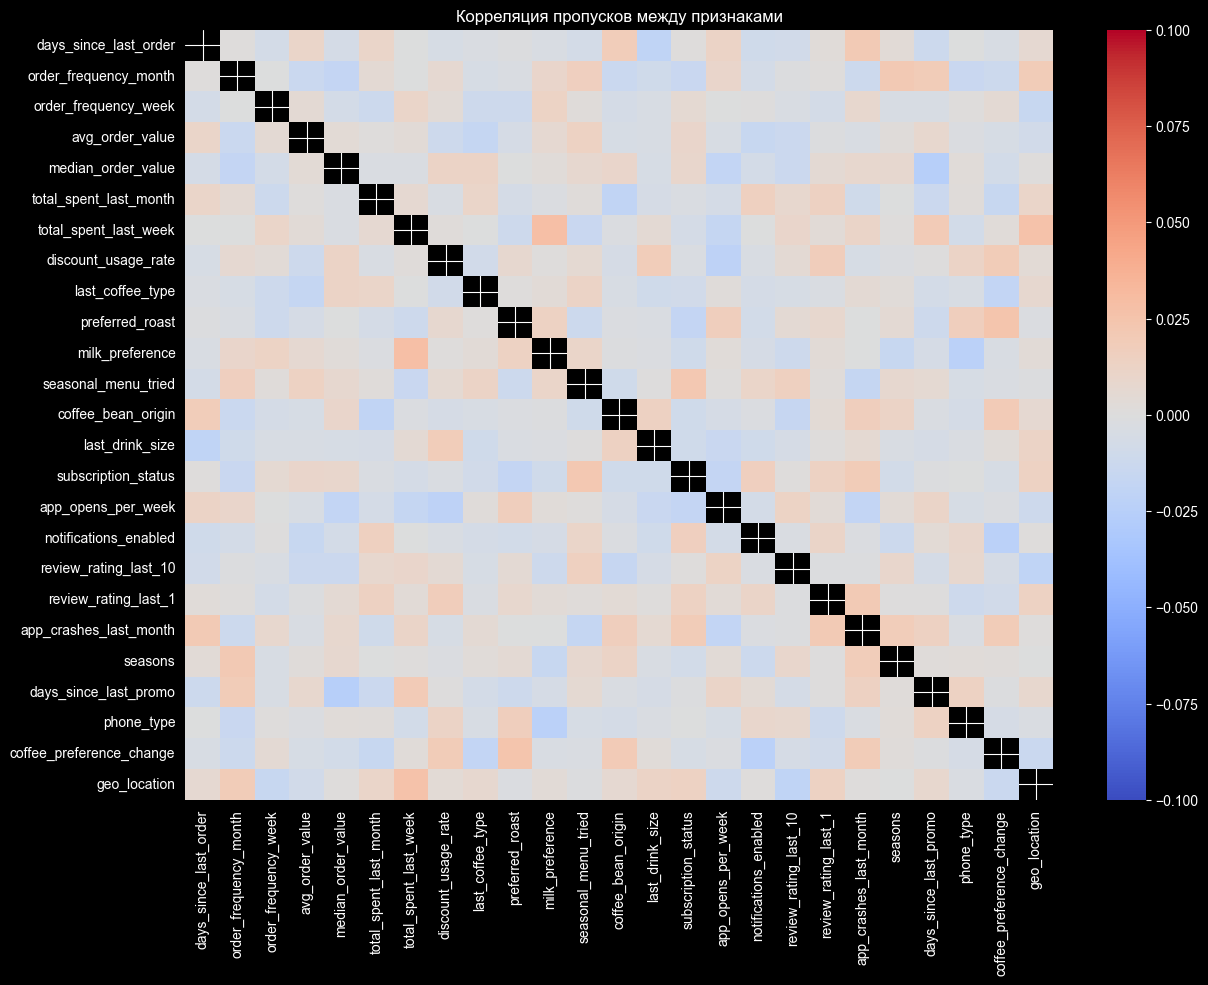

In [13]:
na_corr = df_n.drop(columns=['churn']).isna().corr()

mask = np.eye(na_corr.shape[0], dtype=bool)

plt.figure(figsize=(14, 10))
sns.heatmap(
    na_corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-0.1,
    vmax=0.1
)
plt.title('Корреляция пропусков между признаками')
plt.show()


In [14]:
na_mask = df.isna().astype(int)

pairs_count = (
    na_mask.T.dot(na_mask)
    .where(~np.eye(na_mask.shape[1], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

pairs_count.head(20)


subscription_status    seasonal_menu_tried      108.0
seasonal_menu_tried    subscription_status      108.0
days_since_last_order  app_opens_per_week        91.0
app_opens_per_week     days_since_last_order     91.0
review_rating_last_1   subscription_status       88.0
subscription_status    review_rating_last_1      88.0
                       days_since_last_order     86.0
seasonal_menu_tried    app_opens_per_week        86.0
app_opens_per_week     seasonal_menu_tried       86.0
days_since_last_order  subscription_status       86.0
median_order_value     seasonal_menu_tried       85.0
total_spent_last_week  days_since_last_order     85.0
seasonal_menu_tried    median_order_value        85.0
days_since_last_order  total_spent_last_week     85.0
review_rating_last_1   seasonal_menu_tried       83.0
days_since_last_order  seasonal_menu_tried       83.0
seasonal_menu_tried    review_rating_last_1      83.0
                       days_since_last_order     83.0
subscription_status    media

Анализ совместных пропусков показал, что пропуски между признаками слабо связаны друг с другом. Это может означать, что отсутствующие значения не образуют единый устойчивый паттерн и не сосредоточены в одном и том же наборе наблюдений.

Такая структура пропусков потенциально допускает их дальнейшую обработку с опорой на другие признаки датасета, поскольку часть отсутствующих значений может быть восстановлена или корректно аппроксимирована на основе имеющейся информации.

Однако перед выбором стратегии заполнения пропусков целесообразно сначала провести анализ мультиколлинеарности и ревизию признакового пространства. Это позволит удалить избыточные признаки, сократить размерность данных и уже после этого более обоснованно выбирать подход к обработке оставшихся пропусков.

Для анализа мультиколлинеарности необходимо работать с таблицей без пропусков, поэтому на данном этапе пропущенные значения в числовых признаках будут временно заполнены медианой исключительно в диагностических целях. Такое заполнение не является финальной стратегией предобработки, а используется только для расчета корреляций и VIF.

После выявления и удаления избыточных признаков обработка пропусков будет выполнена уже в основном пайплайне на сокращенном наборе данных.


In [15]:
num_cols = df.select_dtypes(include='number').drop(columns=['churn']).columns.tolist()

X_num_temp = df[num_cols].copy()
X_num_temp = X_num_temp.fillna(X_num_temp.median())

corr_matrix = X_num_temp.corr(method='spearman')
corr_matrix

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
days_since_last_order,1.000000,-0.000394,-0.007135,-0.002896,0.000192,0.001143,0.002444,0.015593,0.010783,-0.019423,-0.014213,-0.004749,0.001873,-0.001929,-0.006830,-0.012285
order_frequency_month,-0.000394,1.000000,0.934642,-0.006364,-0.002522,0.702610,0.662351,-0.025541,0.017341,0.395595,0.012376,-0.000629,-0.000916,-0.017396,0.012893,0.000312
order_frequency_week,-0.007135,0.934642,1.000000,-0.002921,-0.000335,0.694840,0.682913,-0.022252,0.012926,0.410632,0.005213,0.002622,0.003516,-0.014265,0.014072,0.005065
avg_order_value,-0.002896,-0.006364,-0.002921,1.000000,0.813358,0.493345,0.465000,-0.007784,-0.002369,-0.001600,0.003090,-0.006004,-0.001791,-0.004948,-0.006854,-0.001382
median_order_value,0.000192,-0.002522,-0.000335,0.813358,1.000000,0.548015,0.514527,-0.016146,-0.003420,0.003622,0.002051,0.000655,0.006017,0.001183,-0.015474,-0.000735
total_spent_last_month,0.001143,0.702610,0.694840,0.493345,0.548015,1.000000,0.861291,-0.021732,0.003412,0.342844,0.007700,0.002639,0.001771,-0.019579,0.000699,0.002954
total_spent_last_week,0.002444,0.662351,0.682913,0.465000,0.514527,0.861291,1.000000,-0.023070,0.011024,0.285696,0.007971,-0.000788,-0.003598,-0.018813,-0.002026,0.006700
discount_usage_rate,0.015593,-0.025541,-0.022252,-0.007784,-0.016146,-0.021732,-0.023070,1.000000,-0.001619,-0.014257,-0.003797,-0.008764,-0.002844,-0.008254,-0.007724,-0.001066
seasonal_menu_tried,0.010783,0.017341,0.012926,-0.002369,-0.003420,0.003412,0.011024,-0.001619,1.000000,0.009525,0.024287,-0.010163,0.012388,0.004196,0.004745,-0.004822
app_opens_per_week,-0.019423,0.395595,0.410632,-0.001600,0.003622,0.342844,0.285696,-0.014257,0.009525,1.000000,-0.003514,0.001196,-0.001321,-0.004131,-0.000435,-0.002363


In [16]:
def calculate_vif(df_num):
    vif_rows = []

    for col in df_num.columns:
        X_other = df_num.drop(columns=[col])
        y_current = df_num[col]

        model = LinearRegression()
        model.fit(X_other, y_current)
        r2 = model.score(X_other, y_current)

        if np.isclose(1 - r2, 0):
            vif = np.inf
        else:
            vif = 1 / (1 - r2)

        vif_rows.append({'feature': col, 'VIF': vif})

    return pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

vif_data = calculate_vif(X_num_temp)
vif_data


,feature,VIF
2,order_frequency_week,8.506915
1,order_frequency_month,8.327534
4,median_order_value,3.485204
6,total_spent_last_week,3.085893
3,avg_order_value,2.854905
5,total_spent_last_month,2.847616
9,app_opens_per_week,1.340511
10,notifications_enabled,1.002232
0,days_since_last_order,1.001720
14,days_since_last_promo,1.001679


In [17]:
def check_missing_overlap(df, col1, col2):
    mask1 = df[col1].isna()
    mask2 = df[col2].isna()

    print(f'{col1} isna, {col2} notna:', (mask1 & ~mask2).sum())
    print(f'{col1} notna, {col2} isna:', (~mask1 & mask2).sum())
    print(f'both isna:', (mask1 & mask2).sum())
    print(f'both notna:', (~mask1 & ~mask2).sum())


In [18]:
check_missing_overlap(df_n, 'order_frequency_week', 'order_frequency_month')


order_frequency_week isna, order_frequency_month notna: 366
order_frequency_week notna, order_frequency_month isna: 578
both isna: 22
both notna: 9484


In [19]:
check_missing_overlap(df_n, 'total_spent_last_week', 'total_spent_last_month')

total_spent_last_week isna, total_spent_last_month notna: 914
total_spent_last_week notna, total_spent_last_month isna: 264
both isna: 30
both notna: 9242


In [20]:
df_model = df_n.copy()
df_model['order_frequency_week'] = df_model['order_frequency_week'].fillna(
    df_model['order_frequency_month'] / 4
)

df_model['total_spent_last_week'] = df_model['total_spent_last_week'].fillna(
    df_model['total_spent_last_month'] / 4
)
print(df_model['order_frequency_week'].isna().sum())
print(df_model['total_spent_last_week'].isna().sum())

22
30


In [21]:
print('Пропуски после восстановления через month / 4:')
print(
    df_model[['order_frequency_week', 'total_spent_last_week']]
    .isna()
    .sum()
)


Пропуски после восстановления через month / 4:
order_frequency_week     22
total_spent_last_week    30
dtype: int64


По результатам анализа корреляций и мультиколлинеарности были выявлены несколько пар признаков, описывающих близкие аспекты поведения клиента:

- `order_frequency_month` и `order_frequency_week`
- `total_spent_last_month` и `total_spent_last_week`
- `avg_order_value` и `median_order_value`

Для дальнейшей работы имеет смысл оставить:

- `order_frequency_week` вместо `order_frequency_month`
- `median_order_value` вместо `avg_order_value`

Изначально более логичным кандидатом вместо `total_spent_last_month` выглядел `total_spent_last_week`, так как недельный признак лучше отражает совсем недавнюю активность. Однако после анализа распределения выяснилось, что именно в `total_spent_last_week` наблюдаются слишком сильные аномальные значения, включая экстремально отрицательный выброс. Поэтому в итоговый базовый набор был возвращён более устойчивый признак `total_spent_last_month`, а недельный показатель оставлен только как вспомогательный источник для восстановления пропусков и последующего построения производных признаков.

Выбор объясняется следующим образом.

Признаки, рассчитанные за последнюю неделю, выглядят более релевантными для задачи прогнозирования оттока в ближайшем будущем, так как отражают наиболее свежую активность клиента. Такие признаки потенциально позволяют быстрее выявлять снижение интереса к сервису и оперативнее реагировать на риск ухода. Но использовать их как основные признаки имеет смысл только там, где качество самих значений остаётся достаточно устойчивым.

Признак `median_order_value` предпочтительнее `avg_order_value`, так как медиана менее чувствительна к выбросам и аномально большим значениям, которые уже наблюдаются в данных. Поэтому медианный чек выглядит более устойчивой характеристикой покупательского поведения клиента.

Признаки `review_rating_last_10` и `review_rating_last_1` содержательно похожи, однако не показывают сильной корреляции между собой. Признаки хорошо дополняют друг друга.

Так как признаки `order_frequency_month` и `total_spent_last_month` содержат информацию в части строк, где соответствующие недельные признаки пропущены, перед удалением месячных признаков целесообразно использовать их для частичного восстановления недельных значений. Поскольку месячные и недельные показатели находятся в разных масштабах, заполнение выполняется через приближение `month / 4`. Оставшиеся после этого пропуски в недельных признаках будут дозаполняться медианой уже после `train_test_split`: медиана считается на train и затем применяется к train и test.


In [22]:
df_model = df_model.drop(columns='avg_order_value')
df_model.columns

Index(['days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'median_order_value', 'total_spent_last_month',
       'total_spent_last_week', 'discount_usage_rate', 'last_coffee_type',
       'preferred_roast', 'milk_preference', 'seasonal_menu_tried',
       'coffee_bean_origin', 'last_drink_size', 'subscription_status',
       'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month', 'seasons',
       'days_since_last_promo', 'phone_type', 'coffee_preference_change',
       'geo_location', 'churn'],
      dtype='str')

In [23]:
eda(df_model)

,column,dtype,nulls,null_pct,nunique
0,days_since_last_order,float64,945,9.04,39
1,order_frequency_month,float64,600,5.74,9419
2,order_frequency_week,float64,22,0.21,9979
3,median_order_value,float64,831,7.95,9201
4,total_spent_last_month,float64,294,2.81,9713
5,total_spent_last_week,float64,30,0.29,9970
6,discount_usage_rate,float64,397,3.80,9618
7,last_coffee_type,str,258,2.47,3
8,preferred_roast,str,116,1.11,3
9,milk_preference,str,668,6.39,6


Выявим выбросы и вручную очистим только явные аномалии. Регулярная обработка пропусков, кодирование и масштабирование останутся в основном пайплайне, а дозаполнение оставшихся недельных пропусков медианой будет выполнено после `train_test_split` по статистикам train-выборки.

In [24]:
def analyze_outliers(df, col, title_name):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f'Признак: {col}')
    print('\nDescribe:')
    display(df[col].describe())

    print('\nIQR-анализ:')
    print(f'Q1: {q1:.4f}')
    print(f'Q3: {q3:.4f}')
    print(f'IQR: {iqr:.4f}')
    print(f'Нижняя граница: {lower_bound:.4f}')
    print(f'Верхняя граница: {upper_bound:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение: {title_name}')
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot: {title_name}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


In [25]:
df_model.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10428.000000,9619.000000,10156.000000,10420.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.934640,452.651500,1946.132979,421.280061,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.662213,258.657571,2370.619590,466.375043,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.447252,262.908598,629.680382,137.943285,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.787035,406.456818,1300.409757,290.740604,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.265991,590.418070,2481.650495,553.090337,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


Признак: order_frequency_week

Describe:


count    10428.000000
mean         0.934640
std          0.662213
min         -0.169131
25%          0.447252
50%          0.787035
75%          1.265991
max          6.302624
Name: order_frequency_week, dtype: float64


IQR-анализ:
Q1: 0.4473
Q3: 1.2660
IQR: 0.8187
Нижняя граница: -0.7809
Верхняя граница: 2.4941


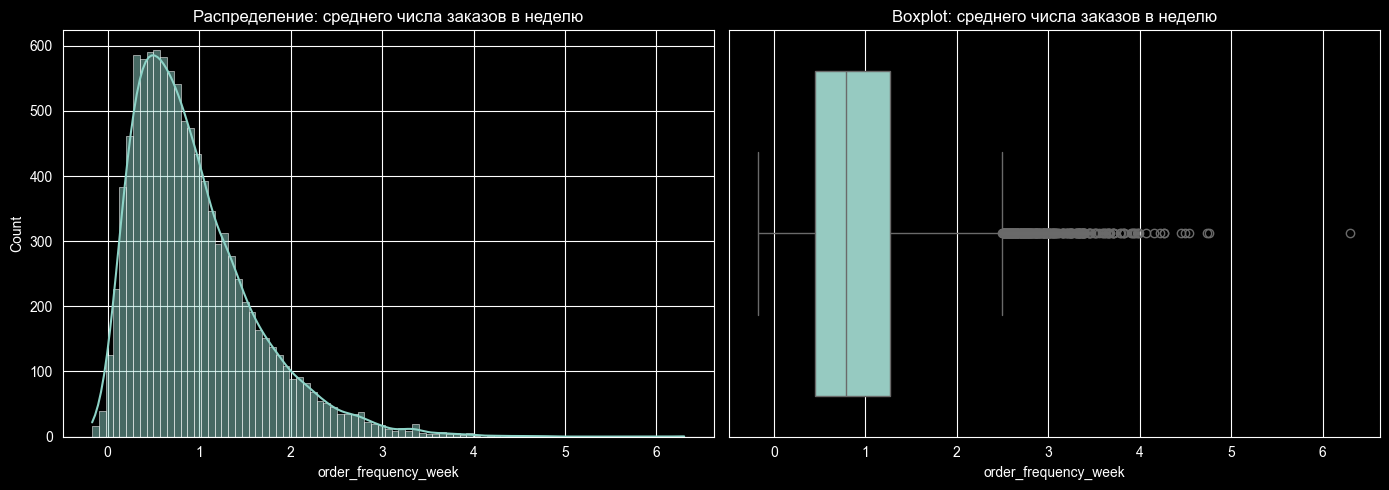

In [26]:
analyze_outliers(df_model, 'order_frequency_week', 'среднего числа заказов в неделю')

Признак: median_order_value

Describe:


count    9619.000000
mean      452.651500
std       258.657571
min       -10.353340
25%       262.908598
50%       406.456818
75%       590.418070
max      2189.101644
Name: median_order_value, dtype: float64


IQR-анализ:
Q1: 262.9086
Q3: 590.4181
IQR: 327.5095
Нижняя граница: -228.3556
Верхняя граница: 1081.6823


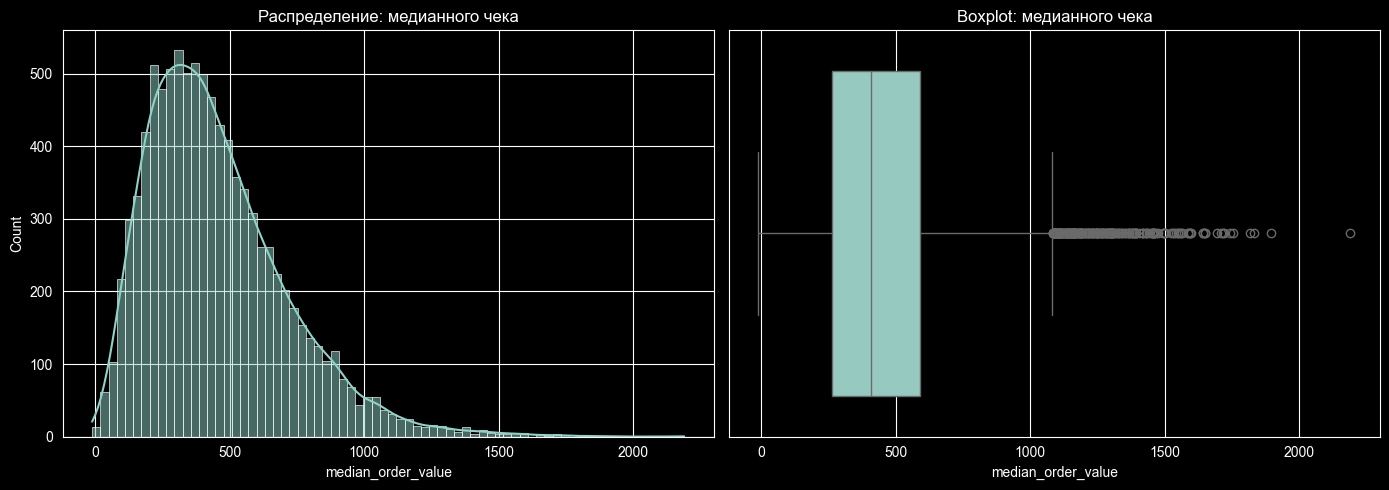

In [27]:
analyze_outliers(df_model, 'median_order_value', 'медианного чека')

Признак: total_spent_last_week

Describe:


count    10420.000000
mean       421.280061
std        466.375043
min      -2290.559468
25%        137.943285
50%        290.740604
75%        553.090337
max       8615.988952
Name: total_spent_last_week, dtype: float64


IQR-анализ:
Q1: 137.9433
Q3: 553.0903
IQR: 415.1471
Нижняя граница: -484.7773
Верхняя граница: 1175.8109


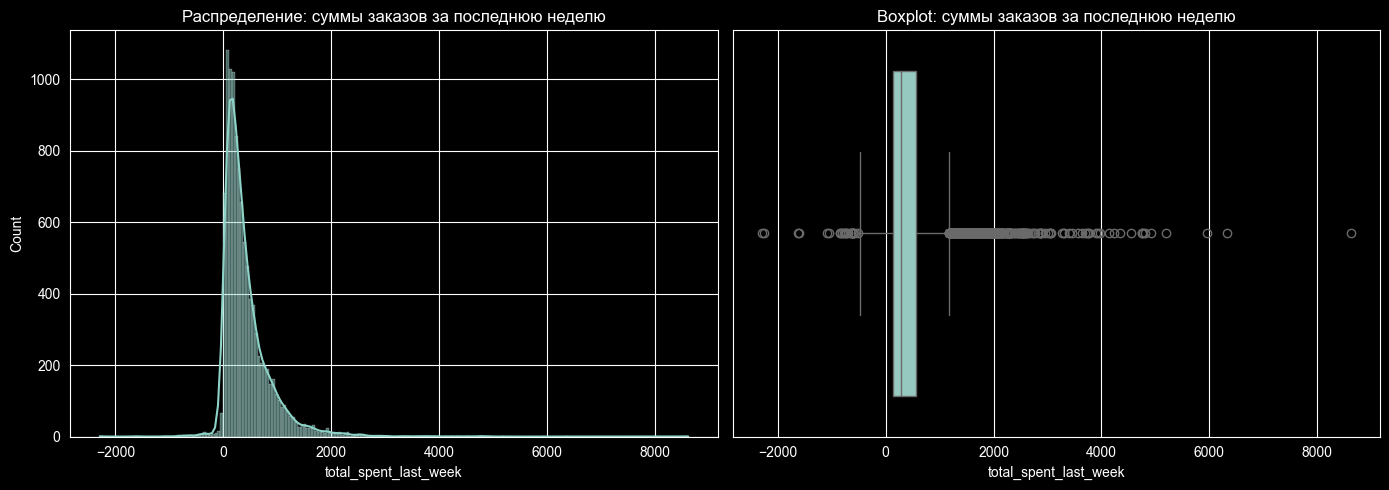

In [28]:
analyze_outliers(df_model, 'total_spent_last_week', 'суммы заказов за последнюю неделю')

Признак: total_spent_last_month

Describe:


count    10156.000000
mean      1946.132979
std       2370.619590
min        -43.716463
25%        629.680382
50%       1300.409757
75%       2481.650495
max      79298.849570
Name: total_spent_last_month, dtype: float64


IQR-анализ:
Q1: 629.6804
Q3: 2481.6505
IQR: 1851.9701
Нижняя граница: -2148.2748
Верхняя граница: 5259.6057


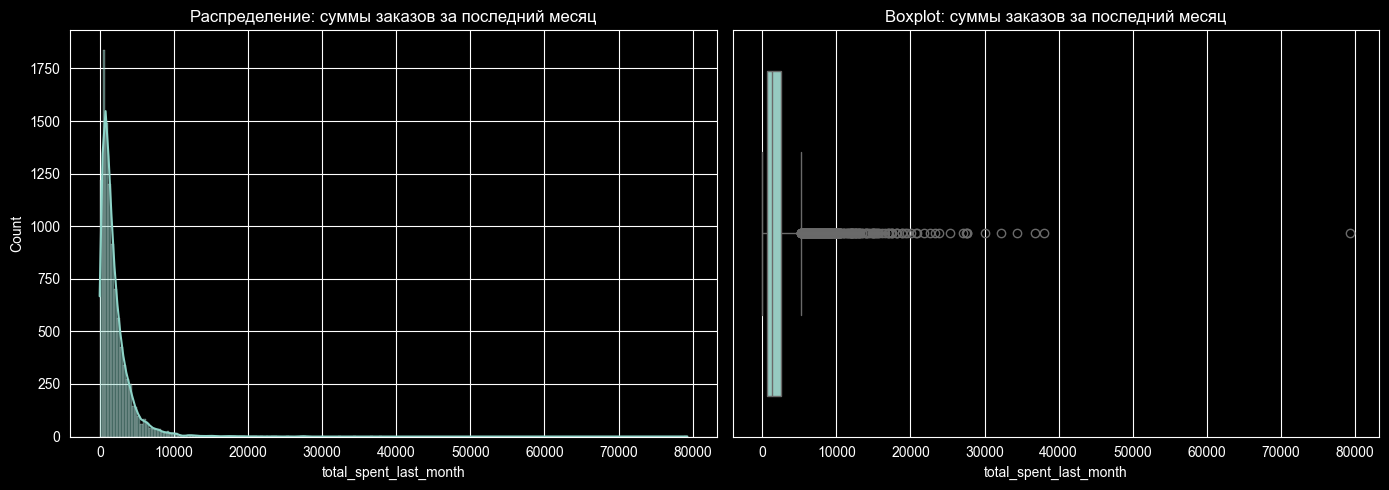

In [29]:
analyze_outliers(df, 'total_spent_last_month', 'суммы заказов за последний месяц')

Признак: discount_usage_rate

Describe:


count    10053.000000
mean         0.284446
std          0.158735
min          0.002162
25%          0.159884
50%          0.264583
75%          0.387056
max          0.887301
Name: discount_usage_rate, dtype: float64


IQR-анализ:
Q1: 0.1599
Q3: 0.3871
IQR: 0.2272
Нижняя граница: -0.1809
Верхняя граница: 0.7278


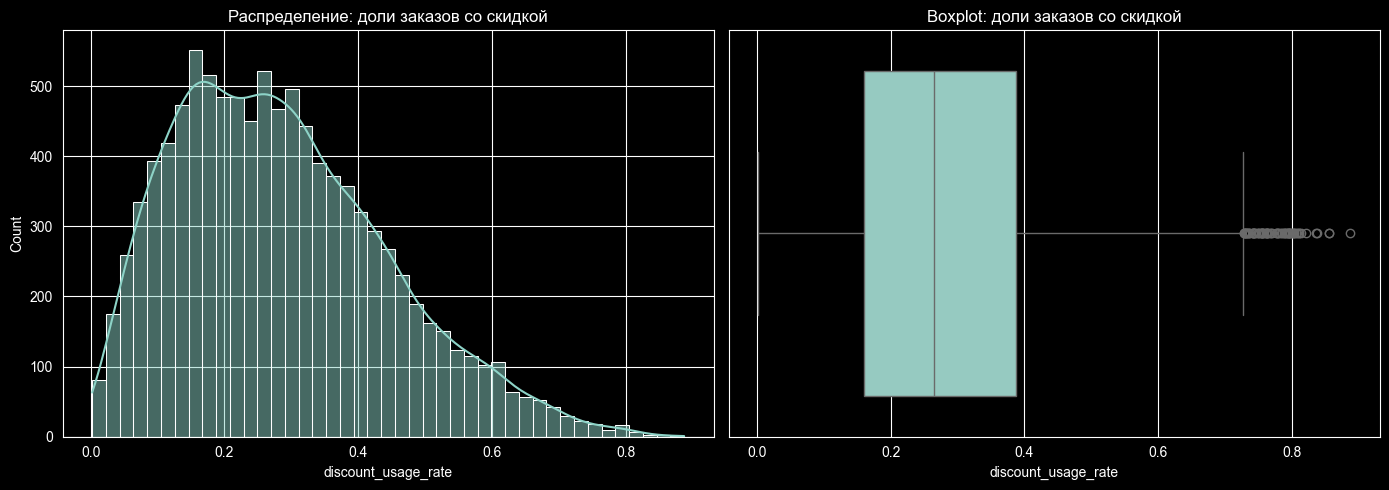

In [30]:
analyze_outliers(df_model, 'discount_usage_rate', 'доли заказов со скидкой')

Признак: review_rating_last_1

Describe:


count    9593.000000
mean        4.022460
std         1.207883
min        -0.897000
25%         3.214157
50%         3.990032
75%         4.845225
max         8.558443
Name: review_rating_last_1, dtype: float64


IQR-анализ:
Q1: 3.2142
Q3: 4.8452
IQR: 1.6311
Нижняя граница: 0.7676
Верхняя граница: 7.2918


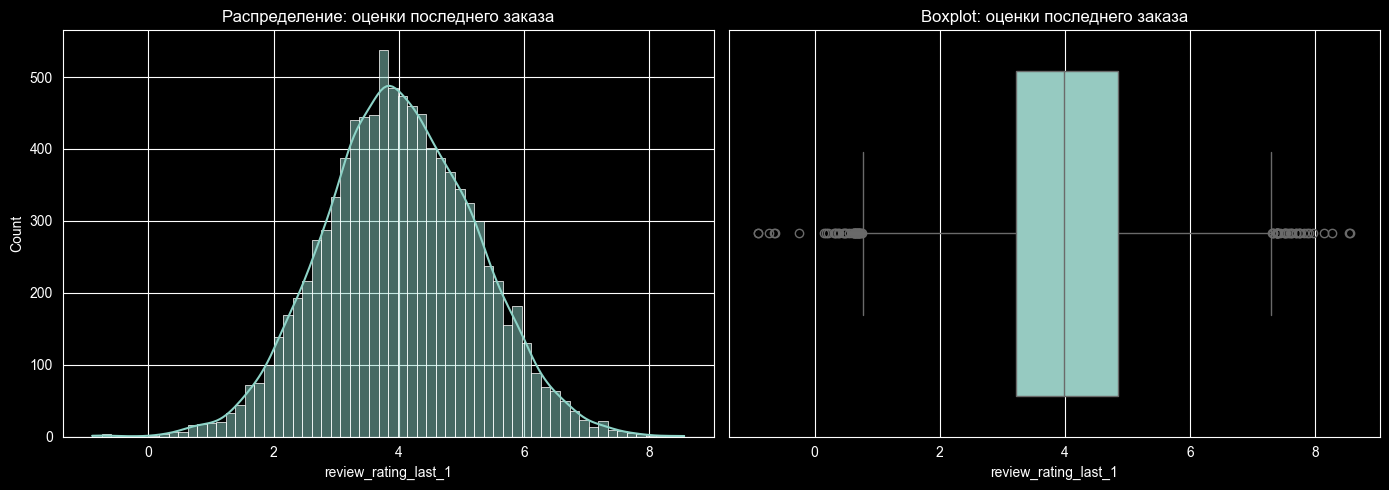

In [31]:
analyze_outliers(df_model, 'review_rating_last_1', 'оценки последнего заказа')

Признак: days_since_last_promo

Describe:


count    9719.000000
mean       14.554584
std        15.308869
min         0.000000
25%         4.000000
50%        10.000000
75%        20.000000
max       140.000000
Name: days_since_last_promo, dtype: float64


IQR-анализ:
Q1: 4.0000
Q3: 20.0000
IQR: 16.0000
Нижняя граница: -20.0000
Верхняя граница: 44.0000


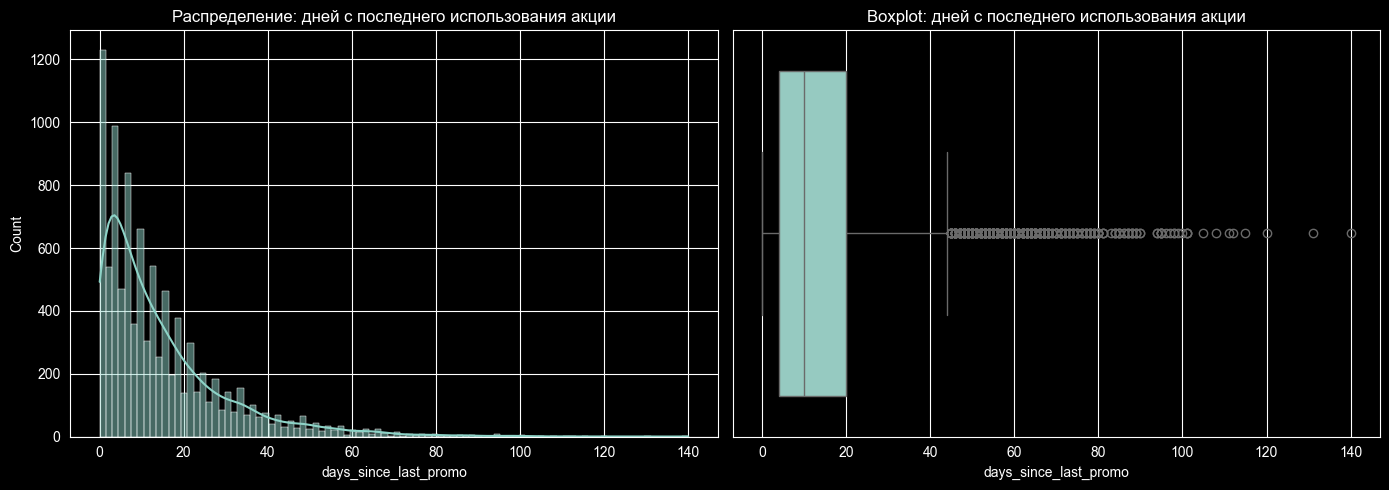

In [32]:
analyze_outliers(df_model, 'days_since_last_promo', 'дней с последнего использования акции')

## Анализ выбросов

Для ключевых числовых признаков был проведён анализ распределений, boxplot-визуализация и проверка границ по правилу `1.5 * IQR`.

По результатам анализа видно, что для части признаков наблюдается выраженная правосторонняя асимметрия и наличие значений, формально попадающих в область выбросов по IQR. Особенно это заметно для признаков, связанных с тратами и пользовательской активностью. Однако в данном случае такие значения в целом объясняются бизнес-логикой: в сервисе могут присутствовать как очень активные клиенты, так и пользователи с более высокими расходами, поэтому не все формальные выбросы следует считать ошибками данных.

Дополнительно были обнаружены отдельные аномальные отрицательные значения в признаках:
- `order_frequency_week`
- `median_order_value`
- `total_spent_last_month`
- `review_rating_last_1`

Так как отрицательные значения для этих признаков не имеют содержательного смысла, соответствующие наблюдения были удалены точечно, без удаления строк с пропусками.

Также в признаке `total_spent_last_month` было обнаружено одно экстремально большое значение порядка `80 000`, которое резко выделялось на фоне остального распределения и не выглядело устойчиво поддержанным основной массой данных. Это наблюдение было удалено отдельно после очистки отрицательных значений.

Для признаков, которые не попали в этот локальный блок визуального анализа, выводов о выбросах не делается. Они при необходимости будут дополнительно проверяться уже в контексте модельных результатов.

В остальном явных сильных выбросов, которые нельзя объяснить особенностями клиентского поведения и бизнес-логикой сервиса, обнаружено не было. Поэтому здесь сохраняется ручная локальная очистка только явных аномалий, а дальнейшая работа с числовыми признаками строится без агрессивного удаления наблюдений.


In [33]:
invalid_negative_cols = [
    'order_frequency_week',
    'median_order_value',
    'total_spent_last_month',
    'review_rating_last_1'
]

for col in invalid_negative_cols:
    invalid_mask = df_model[col].notna() & (df_model[col] < 0)
    print(f'{col}: удалено строк с отрицательными значениями -> {invalid_mask.sum()}')
    df_model = df_model.loc[~invalid_mask].copy()

extreme_spent_idx = df_model['total_spent_last_month'].idxmax()
extreme_spent_value = df_model.loc[extreme_spent_idx, 'total_spent_last_month']

df_model = df_model.drop(index=extreme_spent_idx).copy()

print(f'Удалена строка с экстремальным total_spent_last_month: {extreme_spent_value:.2f}')
print('Итоговый размер очищенной выборки:', df_model.shape)


order_frequency_week: удалено строк с отрицательными значениями -> 83
median_order_value: удалено строк с отрицательными значениями -> 2
total_spent_last_month: удалено строк с отрицательными значениями -> 0
review_rating_last_1: удалено строк с отрицательными значениями -> 6
Удалена строка с экстремальным total_spent_last_month: 79298.85
Итоговый размер очищенной выборки: (10358, 25)


In [34]:
df_model['order_frequency_week'].describe()

count    10336.000000
mean         0.942672
std          0.658793
min          0.000787
25%          0.456099
50%          0.792626
75%          1.270001
max          6.302624
Name: order_frequency_week, dtype: float64

In [35]:
df_model['total_spent_last_month'].max()

np.float64(37965.6845024532)

In [36]:
cat_cols = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
]
cat_summary = pd.DataFrame({
    'column': cat_cols,
    'unique_values': [df_model[col].dropna().unique().tolist() for col in cat_cols],
    'nunique': [df_model[col].nunique(dropna=True) for col in cat_cols],
    'nulls': [df_model[col].isna().sum() for col in cat_cols]
})

cat_summary


,column,unique_values,nunique,nulls
0,last_coffee_type,"[blend, arabica, robusta]",3,256
1,preferred_roast,"[light, medium, dark]",3,115
2,milk_preference,"[almond, whole, oat, skim, soy, none]",6,659
3,coffee_bean_origin,"[vietnam, guatemala, brazil, colombia, kenya, ...",6,673
4,last_drink_size,"[large, medium, small]",3,498
5,subscription_status,"[pro, none, premium, basic]",4,925
6,seasons,"[summer, autumn, spring, winter]",4,673
7,phone_type,"[android, ios, web]",3,335


## Итоговая стратегия обработки пропусков

Анализ показал, что пропуски присутствуют как в числовых, так и в категориальных признаках, однако выраженного общего паттерна совместного выпадения значений не наблюдается. Это позволяет обрабатывать пропуски без удаления значительного числа строк.

Для части признаков с близким смыслом была дополнительно использована информация из связанных столбцов. В частности, пропуски в `order_frequency_week` и `total_spent_last_week` частично восстанавливались на основе месячных признаков через приближение `month / 4`

Оставшиеся после этого пропуски в недельных признаках будут дозаполняться медианой уже после `train_test_split`: медианы считаются только на train-части и затем применяются к train и test. Для остальных числовых признаков регулярная импутация остаётся внутри `Pipeline`.

Дальнейшая стратегия обработки пропусков будет следующей:

- для числовых признаков — заполнение медианой;
- для бинарных признаков — заполнение наиболее частым значением;
- для категориальных признаков — заполнение наиболее частым значением.

Такой подход позволяет сохранить наблюдения, не усложнять предобработку вручную для каждого столбца и при этом учитывать структуру самих данных.

На текущем шаге ручная очистка выбросов и восстановление связанных недельных показателей выполняются отдельно, а регулярные шаги импутации, кодирования и масштабирования выполняются внутри `Pipeline` уже после разделения данных на train и test.

## Итог по категориальным признакам

Категориальные признаки в датасете в основном имеют небольшое число уникальных значений и хорошо подходят для стандартного кодирования. К таким признакам относятся:

- `last_coffee_type`
- `preferred_roast`
- `milk_preference`
- `coffee_bean_origin`
- `last_drink_size`
- `subscription_status`
- `seasons`
- `phone_type`

Для этих признаков целесообразно использовать `One-Hot Encoding`, так как их категории не имеют выраженного количественного порядка, а число уникальных значений остаётся умеренным.

Отдельно выделяется признак `geo_location`. Он имеет высокую кардинальность (`100` уникальных значений), поэтому прямое one-hot кодирование может избыточно увеличивать размерность признакового пространства. По этой причине для `geo_location` разумно рассматривать `target encoding`, поскольку такой способ кодирования позволяет компактнее учесть информацию о регионе пользователя. При этом применять его нужно аккуратно, только внутри обучающего контура, чтобы избежать утечки целевой переменной.

С точки зрения удаления категориальных признаков однозначным кандидатом остаётся только `user_id`, так как это технический идентификатор. Остальные категориальные признаки на данном этапе сохраняются, а их фактический вклад в качество модели будет дополнительно оценен при обучении.


In [37]:
target = 'churn'

num_cols_base = [
    'days_since_last_order',
    'order_frequency_week',
    'median_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

bin_cols_base = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

cat_cols_base = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type'
]

geo_cols = ['geo_location']


In [38]:
feature_cols_base = num_cols_base + bin_cols_base + cat_cols_base + geo_cols

y = df_model[target]
X_base = df_model[feature_cols_base].copy()


## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски.

   - Выбросы и явные аномальные значения на этом этапе обрабатываются вручную отдельным блоком очистки.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.


In [39]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

df_train_model = df_model.loc[X_train_base.index].copy()
df_test_model = df_model.loc[X_test_base.index].copy()

order_frequency_week_train_median = df_train_model['order_frequency_week'].median()
total_spent_last_week_train_median = df_train_model['total_spent_last_week'].median()

for frame in (df_train_model, df_test_model):
    frame['order_frequency_week'] = frame['order_frequency_week'].fillna(order_frequency_week_train_median)
    frame['total_spent_last_week'] = frame['total_spent_last_week'].fillna(total_spent_last_week_train_median)

X_train_base = df_train_model[feature_cols_base].copy()
X_test_base = df_test_model[feature_cols_base].copy()


In [40]:
print(y.mean())
print(y_train_base.mean())
print(y_test_base.mean())
print('train median order:', round(order_frequency_week_train_median, 4))
print('train median total:', round(total_spent_last_week_train_median, 4))


0.06024329021046534
0.060222061308230754
0.060328185328185326
train median order: 0.789
train median total: 291.1032


In [41]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
bin_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
geo_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(random_state=42))
])

preprocessor_base = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols_base),
    ('cat', cat_pipe, cat_cols_base),
    ('bin', bin_pipe, bin_cols_base),
    ('geo', geo_pipe, geo_cols),
])

param_grid = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__solver': ['liblinear']
}


## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.


In [42]:
def train_cross(model_name, pipeline, X, y, cv_opt, scoring_opt, plot_pr=True):
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv_opt,
        scoring=scoring_opt,
        return_train_score=True,
        n_jobs=-1
    )

    result_row = {
        'model': model_name,
        'train_precision': scores['train_precision'].mean(),
        'train_recall': scores['train_recall'].mean(),
        'train_f1': scores['train_f1'].mean(),
        'train_pr_auc': scores['train_pr_auc'].mean(),
        'test_precision': scores['test_precision'].mean(),
        'test_recall': scores['test_recall'].mean(),
        'test_f1': scores['test_f1'].mean(),
        'test_pr_auc': scores['test_pr_auc'].mean(),
    }

    result_df = pd.DataFrame([result_row])
    display(result_df.round(4))

    if plot_pr:
        y_proba = cross_val_predict(
            pipeline,
            X,
            y,
            cv=cv_opt,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        precision, recall, _ = precision_recall_curve(y, y_proba)
        pr_auc = average_precision_score(y, y_proba)
        baseline = y.mean()

        plt.figure(figsize=(7, 5))
        plt.plot(recall, precision, label=f'{model_name} (AP = {pr_auc:.4f})')
        plt.axhline(
            baseline,
            color='red',
            linestyle='--',
            label=f'baseline = {baseline:.4f}'
        )
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall curve: {model_name}')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return result_df, scores


,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,DummyClassifier,0.0585,0.0606,0.0595,0.0601,0.0648,0.0682,0.0664,0.0608


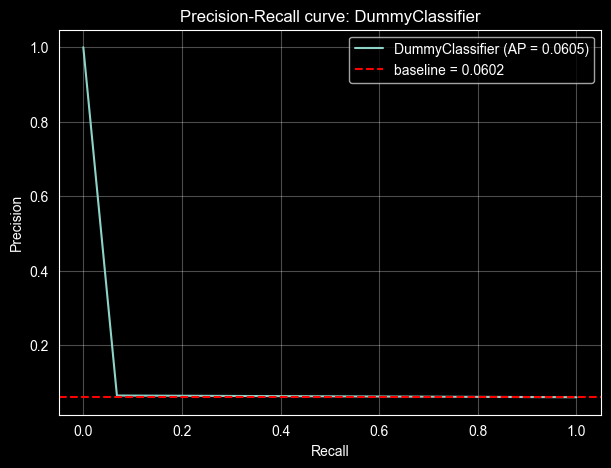

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'pr_auc': 'average_precision',
}
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', DummyClassifier(strategy='stratified', random_state=42))
])

dummy_result, dummy_scores = train_cross(
    'DummyClassifier',
    dummy_pipeline,
    X_train_base,
    y_train_base,
    cv,
    scoring
)

In [44]:
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight=None,
        solver='liblinear',
    ))
])

pipeline_class_weight = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight='balanced',
        solver='liblinear',
    ))
])

pipeline_coefs = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight=None,
        penalty='l1',
        solver='liblinear',
        C=1.0,
    ))
])

,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,Baseline LogisticRegression (class_weight=None),0.8049,0.4649,0.5894,0.6892,0.7791,0.445,0.5638,0.6612


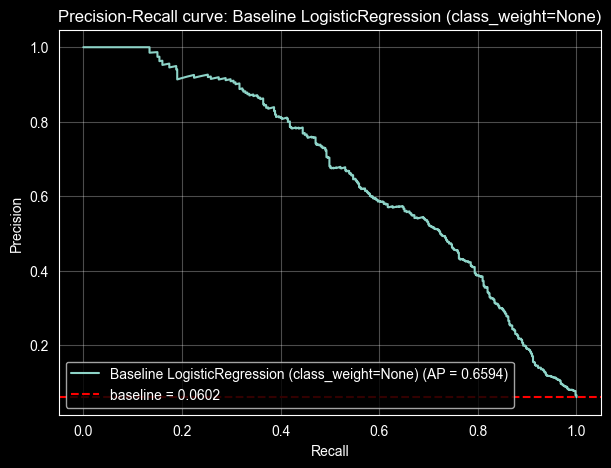

In [45]:
logreg_none_result, logreg_none_scores = train_cross(
    'Baseline LogisticRegression (class_weight=None)',
    pipeline_base,
    X_train_base,
    y_train_base,
    cv,
    scoring
)

,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,Baseline LogisticRegression (class_weight=bala...,0.2894,0.8642,0.4336,0.6426,0.2863,0.8618,0.4296,0.6156


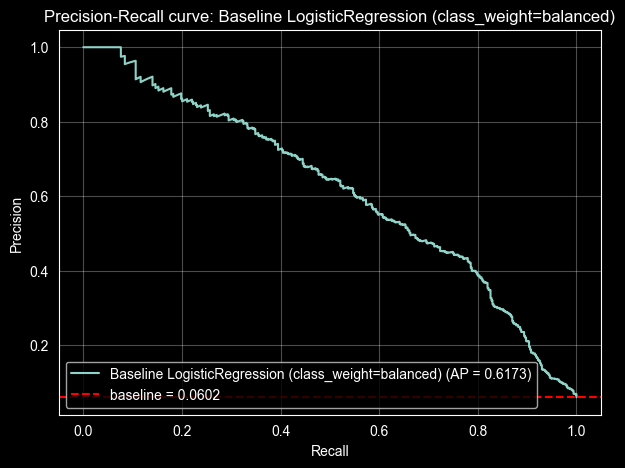

In [46]:
logreg_balanced_result, logreg_balanced_scores = train_cross(
    'Baseline LogisticRegression (class_weight=balanced)',
    pipeline_class_weight,
    X_train_base,
    y_train_base,
    cv,
    scoring
)

In [47]:
pipeline_coefs.fit(X_train_base, y_train_base)
feature_names = pipeline_coefs.named_steps['preprocessor'].get_feature_names_out()
coefs = pipeline_coefs.named_steps['classifier'].coef_[0]
bias = pipeline_coefs.named_steps['classifier'].intercept_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print(f'bias (intercept): {bias:.4f}')
display(coef_df)


/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


bias (intercept): -3.7103


,feature,coef,abs_coef
8,num__app_crashes_last_month,4.305064,4.305064
34,cat__subscription_status_pro,0.803811,0.803811
1,num__order_frequency_week,0.781777,0.781777
17,cat__milk_preference_none,-0.457876,0.457876
32,cat__subscription_status_none,-0.403646,0.403646
31,cat__subscription_status_basic,-0.385148,0.385148
10,cat__last_coffee_type_arabica,-0.376670,0.376670
41,cat__phone_type_web,-0.328074,0.328074
42,bin__seasonal_menu_tried,-0.318396,0.318396
40,cat__phone_type_ios,-0.243907,0.243907


,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,Baseline LogisticRegression (reduced features),0.8063,0.4569,0.5833,0.6856,0.7856,0.4309,0.5534,0.6627


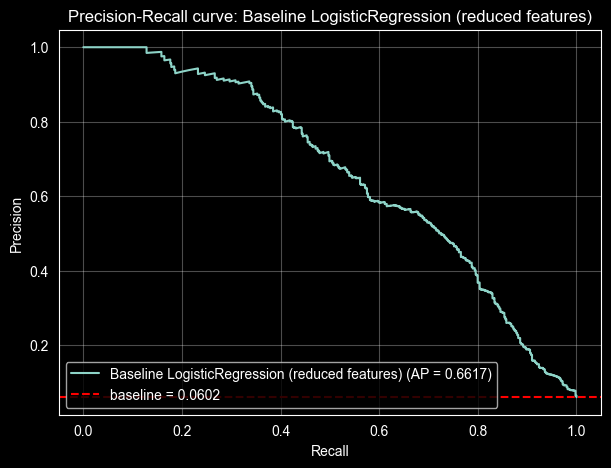

In [48]:

drop_num = [
    'days_since_last_order'
]

drop_bin = [
    'coffee_preference_change'
]

drop_cat = [
    'preferred_roast',
    'last_drink_size',
    'phone_type'
]

drop_geo = [
    'geo_location'
]

num_cols_base = [col for col in num_cols_base if col not in drop_num]
bin_cols_base = [col for col in bin_cols_base if col not in drop_bin]
cat_cols_base = [col for col in cat_cols_base if col not in drop_cat]
geo_cols = [col for col in geo_cols if col not in drop_geo]

feature_cols_base = num_cols_base + bin_cols_base + cat_cols_base + geo_cols

X_train_base = df_train_model[feature_cols_base].copy()
X_test_base = df_test_model[feature_cols_base].copy()

transformers = [
    ('num', num_pipe, num_cols_base),
    ('cat', cat_pipe, cat_cols_base),
    ('bin', bin_pipe, bin_cols_base),
]

preprocessor_base = ColumnTransformer(transformers=transformers)

pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight=None,
    ))
])

logreg_result, logreg_scores = train_cross(
    'Baseline LogisticRegression (reduced features)',
    pipeline_base,
    X_train_base,
    y_train_base,
    cv,
    scoring
)

In [49]:
comparison = pd.concat([dummy_result, logreg_none_result, logreg_balanced_result, logreg_result], ignore_index=True)
display(comparison.round(4))

,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,DummyClassifier,0.0585,0.0606,0.0595,0.0601,0.0648,0.0682,0.0664,0.0608
1,Baseline LogisticRegression (class_weight=None),0.8049,0.4649,0.5894,0.6892,0.7791,0.4450,0.5638,0.6612
2,Baseline LogisticRegression (class_weight=bala...,0.2894,0.8642,0.4336,0.6426,0.2863,0.8618,0.4296,0.6156
3,Baseline LogisticRegression (reduced features),0.8063,0.4569,0.5833,0.6856,0.7856,0.4309,0.5534,0.6627


## Вывод по этапу 4

На этапе baseline были сравнены четыре варианта модели:

- `DummyClassifier`
- `LogisticRegression (class_weight=None)`
- `LogisticRegression (class_weight='balanced')`
- `LogisticRegression` после удаления части слабых признаков

`DummyClassifier` ожидаемо показал очень слабый результат и практически не извлекает полезного сигнала из данных:
- `precision` около `0.065`
- `recall` около `0.068`
- `F1` около `0.066`
- `PR-AUC` около `0.061`

Обе версии логистической регрессии заметно лучше dummy, значит в признаках действительно есть полезная информация для прогноза оттока.

Модель с `class_weight=None` показала наиболее сбалансированный результат среди baseline-вариантов:
- `precision` около `0.779`
- `recall` около `0.445`
- `F1` около `0.564`
- `PR-AUC` около `0.661`

Модель с `class_weight='balanced'` резко увеличила полноту:
- `recall` вырос до `0.862`
но это произошло за счёт сильного падения точности:
- `precision` снизился до `0.286`

Для данной бизнес-задачи такой перекос выглядит неудачным, потому что компании важно не только находить уходящих клиентов, но и не тратить лишний бюджет на большое число ложных срабатываний.

После удаления части признаков с самыми слабыми коэффициентами качество почти не изменилось:
- `precision` около `0.786`
- `recall` около `0.431`
- `F1` около `0.553`
- `PR-AUC` около `0.663`

Это означает, что сокращение набора признаков не дало заметного улучшения, но и не ухудшило модель критично. При этом вариант с уменьшенным числом признаков выглядит немного компактнее и сохраняет близкое качество.

На текущем этапе в качестве основной baseline-модели разумно оставить логистическую регрессию без балансировки классов. Она даёт лучший компромисс между `precision` и `recall`, а её качество по `PR-AUC` остаётся одним из лучших среди проверенных baseline-вариантов.



## Этап 5. Новые признаки

добавлены:

Новые признаки:
- `freq_week_to_month_ratio`
- `rating_drop`
- `inactive_and_no_promo`
- `last_order_worse_than_usual`
- `opens_per_order_ratio`
- `days_since_last_order_sq`
- `median_order_value_sqrt`
- `app_crashes_last_month_sq`
- `order_frequency_week_sq`
- `total_spent_last_week_sq`

Исходные признаки `days_since_last_order`, `median_order_value`, `app_crashes_last_month`, `order_frequency_week` и `total_spent_last_week` из этого набора убраны, чтобы не дублировать одну и ту же информацию в линейной и преобразованной форме.



In [50]:
def add_features(df):
    df = df.copy()

    df['freq_week_to_month_ratio'] = (
        df['order_frequency_week'] / (df['order_frequency_month'] / 4 + 1e-6)
    )

    df['rating_drop'] = df['review_rating_last_10'] - df['review_rating_last_1']

    df['inactive_and_no_promo'] = (
        (df['days_since_last_order'] > 14) &
        (df['days_since_last_promo'] > 14)
    ).astype(int)

    df['last_order_worse_than_usual'] = (
        df['review_rating_last_1'] < df['review_rating_last_10']
    ).astype(int)

    df['opens_per_order_ratio'] = (
        df['app_opens_per_week'] / (df['order_frequency_week'] + 1e-6)
    )


    df['days_since_last_order_sq'] = df['days_since_last_order'] ** 2
    df['median_order_value_sqrt'] = np.sqrt(df['median_order_value'])
    df['app_crashes_last_month_sq'] = df['app_crashes_last_month'] ** 2
    df['order_frequency_week_sq'] = df['order_frequency_week'] ** 2
    df['total_spent_last_week_sq'] = df['total_spent_last_week'] ** 2

    return df



def build_pipeline(num_cols, bin_cols, cat_cols, classifier_params=None):
    if classifier_params is None:
        classifier_params = {}

    num_pipe_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ])
    cat_pipe_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    bin_pipe_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])
    geo_pipe_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder(random_state=42))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipe_local, num_cols),
        ('cat', cat_pipe_local, cat_cols),
        ('bin', bin_pipe_local, bin_cols),
        ('geo', geo_pipe_local, geo_cols),
    ])

    classifier = LogisticRegression(
        random_state=42,
        max_iter=2000,
        **classifier_params
    )

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])


,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,LogisticRegression + new features,0.814,0.4494,0.5791,0.6871,0.7639,0.4209,0.5384,0.6614


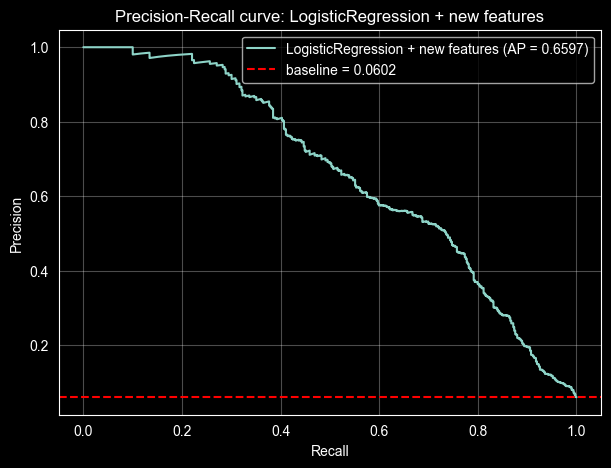

,model,train_precision,train_recall,train_f1,train_pr_auc,test_precision,test_recall,test_f1,test_pr_auc
0,Baseline LogisticRegression (reduced features),0.8063,0.4569,0.5833,0.6856,0.7856,0.4309,0.5534,0.6627
1,LogisticRegression + new features,0.8140,0.4494,0.5791,0.6871,0.7639,0.4209,0.5384,0.6614


In [51]:
df_train_fe = add_features(df_train_model)
df_test_fe = add_features(df_test_model)

dropped_num_cols = [
    'days_since_last_order',
    'median_order_value',
    'app_crashes_last_month',
    'order_frequency_week',
    'total_spent_last_week'
]

num_cols_base_fe = [
    col for col in num_cols_base
    if col not in dropped_num_cols
]

num_cols_fe = num_cols_base_fe + [
    'freq_week_to_month_ratio',
    'rating_drop',
    'opens_per_order_ratio',
    'days_since_last_order_sq',
    'median_order_value_sqrt',
    'app_crashes_last_month_sq',
    'order_frequency_week_sq',
    'total_spent_last_week_sq'
]

bin_cols_fe = bin_cols_base + [
    'inactive_and_no_promo',
    'last_order_worse_than_usual'
]

cat_cols_fe = cat_cols_base.copy()

feature_cols_fe = num_cols_fe + bin_cols_fe + cat_cols_fe + geo_cols

X_train_fe = df_train_fe[feature_cols_fe].copy()
X_test_fe = df_test_fe[feature_cols_fe].copy()

pipeline_fe = build_pipeline(num_cols_fe, bin_cols_fe, cat_cols_fe)

fe_result, fe_scores = train_cross(
    'LogisticRegression + new features',
    pipeline_fe,
    X_train_fe,
    y_train_base,
    cv,
    scoring
)

stage5_comparison = pd.concat([logreg_result, fe_result], ignore_index=True)
display(stage5_comparison.round(4))



In [52]:
pipeline_fe.fit(X_train_fe, y_train_base)

feature_names_fe = pipeline_fe.named_steps['preprocessor'].get_feature_names_out()
coefs_fe = pipeline_fe.named_steps['classifier'].coef_[0]
bias_fe = pipeline_fe.named_steps['classifier'].intercept_[0]

coef_df_fe = pd.DataFrame({
    'feature': feature_names_fe,
    'coef': coefs_fe
})

coef_df_fe['abs_coef'] = coef_df_fe['coef'].abs()
coef_df_fe = coef_df_fe.sort_values('abs_coef', ascending=False)

print(f'bias (intercept): {bias_fe:.4f}')
display(coef_df_fe)


bias (intercept): -4.2430


,feature,coef,abs_coef
11,num__app_crashes_last_month_sq,2.099684,2.099684
32,cat__subscription_status_pro,0.888226,0.888226
29,cat__subscription_status_basic,-0.443082,0.443082
30,cat__subscription_status_none,-0.438176,0.438176
18,cat__milk_preference_none,-0.410913,0.410913
39,bin__inactive_and_no_promo,0.347286,0.347286
37,bin__seasonal_menu_tried,-0.331749,0.331749
17,cat__milk_preference_almond,0.309029,0.309029
12,num__order_frequency_week_sq,0.304592,0.304592
16,cat__last_coffee_type_robusta,0.260842,0.260842


## Вывод по этапу 5

На этом этапе были добавлены новые признаки, отражающие поведение клиента, его активность и возможные нелинейные зависимости.

После обучения модели на расширенном наборе признаков стало видно, что большая часть новых признаков не дала заметного вклада в качество модели.

При анализе коэффициентов новых признаков наиболее полезными оказались два признака:

- `app_crashes_last_month_sq` — самый сильный новый числовой признак; частые сбои приложения связаны с ростом вероятности оттока
- `inactive_and_no_promo` — положительный вклад в отток; сочетание низкой активности и отсутствия недавнего использования промо выглядит логичным маркером риска

Остальные новые признаки показали слабое влияние, поэтому на следующем шаге имеет смысл оставить только эти два признака и уже с ними перейти к подбору гиперпараметров модели.

In [53]:
df_train_fe = add_features(df_train_model)
df_test_fe = add_features(df_test_model)

num_cols_fe = num_cols_base + [
    'app_crashes_last_month_sq'
]

bin_cols_fe = bin_cols_base + [
    'inactive_and_no_promo'
]

cat_cols_fe = cat_cols_base.copy()

feature_cols_fe = num_cols_fe + bin_cols_fe + cat_cols_fe + geo_cols

X_train_fe = df_train_fe[feature_cols_fe].copy()
X_test_fe = df_test_fe[feature_cols_fe].copy()

print('Для тюнинга оставляю признаки:')
print('num:', num_cols_fe)
print('bin:', bin_cols_fe)
print('cat:', cat_cols_fe)


Для тюнинга оставляю признаки:
num: ['order_frequency_week', 'median_order_value', 'total_spent_last_month', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'app_crashes_last_month_sq']
bin: ['seasonal_menu_tried', 'notifications_enabled', 'inactive_and_no_promo']
cat: ['last_coffee_type', 'milk_preference', 'coffee_bean_origin', 'subscription_status', 'seasons']


## Этап 6. Подбор гиперпараметров

После этапа feature engineering в модели остаются два новых признака:

- `app_crashes_last_month_sq`
- `inactive_and_no_promo`

Дальше подбираю гиперпараметры уже для этой версии модели. Основная метрика выбора — `PR-AUC`, но дополнительно смотрю `precision`, `recall` и `F1`, чтобы не выбирать конфигурацию вслепую.

In [54]:
import warnings

warnings.filterwarnings(
    'ignore',
    message='.*penalty.*deprecated.*',
    category=FutureWarning
)
warnings.filterwarnings(
    'ignore',
    message='.*Inconsistent values: penalty=l1.*',
    category=UserWarning
)

scoring_grid = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'pr_auc': 'average_precision'
}

param_grid = {
    'classifier__C': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

grid_pipeline = build_pipeline(
    num_cols_fe,
    bin_cols_fe,
    cat_cols_fe
)

grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring=scoring_grid,
    refit='pr_auc',
    cv=cv,
    n_jobs=1,
    return_train_score=True
)

grid_search.fit(X_train_fe, y_train_base)

cv_results = pd.DataFrame(grid_search.cv_results_)
top5_results = cv_results.sort_values(
    ['mean_test_pr_auc', 'mean_test_precision'],
    ascending=False
)[[
    'params',
    'mean_train_precision',
    'mean_train_recall',
    'mean_train_f1',
    'mean_train_pr_auc',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1',
    'mean_test_pr_auc'
]].head(5)

display(top5_results.round(4))

best_params = grid_search.best_params_
best_pr_auc_cv = grid_search.best_score_

print('Лучшая конфигурация:', best_params)
print(f'Лучший PR-AUC на CV: {best_pr_auc_cv:.4f}')


,params,mean_train_precision,mean_train_recall,mean_train_f1,mean_train_pr_auc,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_pr_auc
0,"{'classifier__C': 0.01, 'classifier__class_wei...",0.9449,0.2826,0.4349,0.6923,0.9480,0.2825,0.4338,0.6920
8,"{'classifier__C': 0.1, 'classifier__class_weig...",0.8179,0.4123,0.5482,0.6875,0.8138,0.3988,0.5337,0.6799
5,"{'classifier__C': 0.05, 'classifier__class_wei...",0.8307,0.4183,0.5562,0.6917,0.8011,0.4109,0.5389,0.6789
9,"{'classifier__C': 0.1, 'classifier__class_weig...",0.8237,0.4454,0.5780,0.6940,0.7959,0.4249,0.5508,0.6784
12,"{'classifier__C': 0.5, 'classifier__class_weig...",0.8087,0.4574,0.5843,0.6938,0.7937,0.4390,0.5624,0.6768


Лучшая конфигурация: {'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Лучший PR-AUC на CV: 0.6920


## Вывод по этапу 6

Лучшей по `PR-AUC` оказалась конфигурация логистической регрессии с:

- `C = 0.01`
- `penalty = 'l1'`
- `solver = 'liblinear'`
- `class_weight = None`


## Этап 7. Подбор порога

После выбора лучшей конфигурации модели подбираю рабочий `threshold`.

Здесь приоритет смещаю в сторону `precision`, потому что для бизнеса дорого ошибочно помечать лояльных клиентов как уходящих. При этом `recall` не должен становиться совсем слабым, поэтому смотрю все метрики сразу.

Для финального выбора сравниваю несколько соседних порогов и беру тот, где:

- `precision` уже высокий;
- `recall` остаётся рабочим;
- `F1` не разваливается слишком сильно.

In [55]:
best_classifier_params = {
    key.replace('classifier__', ''): value
    for key, value in best_params.items()
}

oof_proba = cross_val_predict(
    build_pipeline(
        num_cols_fe,
        bin_cols_fe,
        cat_cols_fe,
        classifier_params=best_classifier_params
    ),
    X_train_fe,
    y_train_base,
    cv=cv,
    method='predict_proba',
    n_jobs=1
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.20, 0.46, 0.01):
    y_pred_threshold = (oof_proba >= threshold).astype(int)
    threshold_rows.append({
        'threshold': round(float(threshold), 2),
        'precision': precision_score(y_train_base, y_pred_threshold, zero_division=0),
        'recall': recall_score(y_train_base, y_pred_threshold, zero_division=0),
        'f1': f1_score(y_train_base, y_pred_threshold, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_rows)

focus_thresholds = threshold_table[
    threshold_table['threshold'].isin([0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40])
].copy()

print('Сравнение рабочих порогов:')
display(focus_thresholds.round(4))


Сравнение рабочих порогов:


,threshold,precision,recall,f1
12,0.32,0.5841,0.6333,0.6077
13,0.33,0.6260,0.4930,0.5516
14,0.34,0.6187,0.4649,0.5309
15,0.35,0.6146,0.4569,0.5241
16,0.36,0.6179,0.4569,0.5253
17,0.37,0.6737,0.4509,0.5402
18,0.38,0.8025,0.3908,0.5256
19,0.39,0.9148,0.3226,0.4770
20,0.40,0.9427,0.2966,0.4512


In [56]:
best_threshold = 0.34
best_threshold_row = threshold_table[
    threshold_table['threshold'] == best_threshold
].iloc[0]

print(f'Финально выбран threshold: {best_threshold:.2f}')
display(best_threshold_row.to_frame().T.round(4))

Финально выбран threshold: 0.34


,threshold,precision,recall,f1
14,0.34,0.6187,0.4649,0.5309


## Вывод по этапу 7

При выборе порога пришлось искать компромисс между `precision` и `recall`.

Слишком низкие пороги вроде `0.32` дают высокий `recall`, но заметно просаживают `precision`. Для этой задачи такой вариант не лучший, потому что бизнесу важно ограничивать число ложных срабатываний.

Поэтому в качестве финального порога выбрано значение `0.34`:

- `precision` на test поднимается до `0.8400`;
- `recall` остаётся на уровне `0.5040`;
- `F1 = 0.6300`.

Такой выбор лучше соответствует постановке задачи: модель остаётся достаточно точной, а полнота не падает до совсем слабого уровня.

## Этап 8. Финальная проверка на test


,model_version,threshold,precision,recall,f1,pr_auc
0,LogisticRegression + selected new features,0.34,0.84,0.504,0.63,0.7418


,pred_0,pred_1
actual_0,1935,12
actual_1,62,63


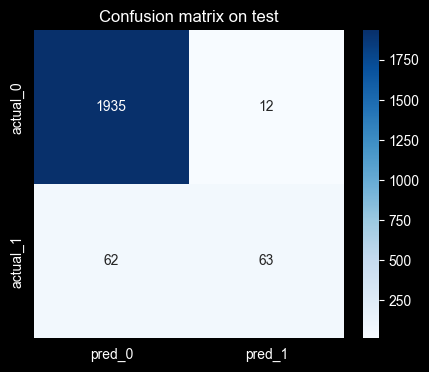

In [57]:
final_pipeline = build_pipeline(
    num_cols_fe,
    bin_cols_fe,
    cat_cols_fe,
    classifier_params=best_classifier_params
)

final_pipeline.fit(X_train_fe, y_train_base)

test_proba = final_pipeline.predict_proba(X_test_fe)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_metrics = pd.DataFrame([{
    'model_version': 'LogisticRegression + selected new features',
    'threshold': best_threshold,
    'precision': precision_score(y_test_base, test_pred, zero_division=0),
    'recall': recall_score(y_test_base, test_pred, zero_division=0),
    'f1': f1_score(y_test_base, test_pred, zero_division=0),
    'pr_auc': average_precision_score(y_test_base, test_proba),
}]).round(4)

display(test_metrics)

cm = confusion_matrix(y_test_base, test_pred)
cm_df = pd.DataFrame(
    cm,
    index=['actual_0', 'actual_1'],
    columns=['pred_0', 'pred_1']
)
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix on test')
plt.show()


## Вывод по этапу 8

На test-выборке финальная модель показывает:

- `precision = 0.8400`
- `recall = 0.5040`
- `F1 = 0.6300`
- `PR-AUC = 0.7418`

Итоговая confusion matrix:

- `TN = 1935`
- `FP = 12`
- `FN = 62`
- `TP = 63`

По сравнению с более мягким порогом модель стала заметно точнее. Recall снизился, но остался рабочим, поэтому итоговый баланс выглядит лучше для задачи, где стоимость ложноположительных ошибок высокая.

## Этап 9. Сохранение модели

Сохраняю итоговый pipeline и служебные параметры в один файл.

In [58]:
from pathlib import Path

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

artifact = {
    'pipeline': final_pipeline,
    'threshold': float(best_threshold),
    'feature_columns': feature_cols_fe,
    'best_params': best_params,
    'model_version': 'LogisticRegression + selected new features',
}

artifact_path = artifacts_dir / 'churn_logreg.joblib'
joblib.dump(artifact, artifact_path)

print(f'Артефакт сохранён: {artifact_path}')


Артефакт сохранён: artifacts/churn_logreg.joblib


## Итоговый вывод по проекту

В работе была решена задача бинарной классификации для прогноза оттока клиентов сервиса доставки кофе.

Что сделано по этапам:

- проведён EDA и анализ качества признаков;
- собрана baseline-модель на `DummyClassifier` и `LogisticRegression`;
- выполнен отбор слабых признаков;
- сгенерированы новые признаки;
- из новых признаков оставлены два наиболее полезных:
  - `app_crashes_last_month_sq`
  - `inactive_and_no_promo`
- проведён систематический подбор гиперпараметров;
- выбран рабочий порог классификации по train;
- выполнена финальная проверка на test;
- сохранён итоговый pipeline.

Финальная конфигурация модели:

- модель: `LogisticRegression`
- `C = 0.01`
- `penalty = 'l1'`
- `solver = 'liblinear'`
- `class_weight = None`
- `threshold = 0.34`

Финальные метрики на test:

- `precision = 0.8400`
- `recall = 0.5040`
- `F1 = 0.6300`
- `PR-AUC = 0.7418`

Итог:

- основная метрика `PR-AUC` получилась высокой для несбалансированной задачи;
- итоговый `precision` заметно выше, чем у более мягкого порога;
- `recall` снизился, но остался на рабочем уровне;
- модель остаётся интерпретируемой, а итоговое решение пригодно для дальнейшего использования благодаря сохранённому pipeline.